<div style="height:2cm;">
<div style="float:center;width:100%;text-align:center;"><strong style="height:100px;color:darkred;font-size:40px;">Writing a Gaussian Elimination Solver</strong>
</div></div>

# 1. Display a Layout of the Gaussian Elimination Algorithm

GE layout rendering is covered in [**A2_Matrix_Layout_Displays.ipynb**](A2_Matrix_Layout_Displays.ipynb).  
Use `LAFigureSpecs.ge_stack_svg(...)` for visualization of the solver actions when needed.

___
The code in this notebook is intended as a debugging aid when writing a Gaussian Elimination Solver:<br>
starting with a matrix $A$,
* we find an elimination matrix $E_1$ and update the matrix to $A_1 = E_1 A$. Save the computation in the augmented matrix [E_1 A_1]
* for each successive step, $E_i, A_i$, update the augmented matrix with [previous_augmented_matrix ; E_i A_i]
Save the pivot locations in the same way.

When the algorithm completes, we have
* the original array $A$
* the computations in another array<br><br>
$\qquad Computations = \begin{array}{rr}
& (A_0) \\
  (E_1) & (A_1) \\
  (E_2) & (A_2) \\
  \dots & \dots
\end{array}
$

and the pivot indices $p_i$ in an array or a list $( p_1, p_2, \dots p_i \dots )$.

The canonical `ge_svg` wrapper can now be used to display the computation.

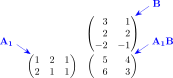

In [17]:
# Display a stack of matrices. Here we use julia
using LATeachingSuite, LATeachingSuite

A = [1 2 1; 2 1 1]
B = [3 1; 2 2; -2 -1]
C = A * B
matrices = [[nothing, B], [A, C]]
h = ge_svg(to_latex(matrices); array_names=["A","B"], array_name_indices=false)
h

# 2. Coding Assignment

## 2.1 Write a Function to Compute a Row Echelon Form of a Matrix A

Create a function that takes a matrix as an input, and returns a corresponding row echelon form.<br>
You might consider using `ge_svg` for display checks, or lower-level layout helpers only for debugging internals.

You may use a `Large Language Model` to write the code as well as `unit tests`

In [2]:
function row_echelon_form(A)
    M,N = size(A)
    println("The matrix A has size $M x $N")
    display(A)

    # make a copy of A: we will modify the copy, not A itself
    R = copy(A)
    # < your code here > ***************************************************** <<<<<<
    R
end;

## 2.2 Some Code Building Blocks

### 2.1.1 Vectors and Matrices

In [3]:
println("A vector:  row_index=1")
A[1, 1:3]

A vector:  row_index=1


3-element Vector{Int64}:
 1
 2
 1

In [4]:
println( "A matrix (row vector): row_index=1:1")
A[1:1, 1:3]

A matrix (row vector): row_index=1:1


1×3 Matrix{Int64}:
 1  2  1

In [5]:
println( "A column vector: transpose of a row vector")
A[1:1,1:3]'

A column vector: transpose of a row vector


3×1 adjoint(::Matrix{Int64}) with eltype Int64:
 1
 2
 1

### 2.1.2 Conditional Statements

In [6]:
if 3 > 1 && 8 < 9
    println( "if branch")
else
    println( "else branch")
end

if branch


### 2.1.3 Loop statements `for loops`

In [7]:
for i in 1:10
    print( " $i")
end

 1 2 3 4 5 6 7 8 9 10

In [8]:
# premature temination of the loop
for i in 1:10
    print( " $i")
    if i > 4
        break
    end
end

 1 2 3 4 5

In [9]:
# skip some code inside a loop
for i in 1:10
    if i > 3 && i < 8
        continue
    end
    print( " $i")
end

 1 2 3 8 9 10

# 2.2 Building Blocs

> * given  a current row and column, find a pivot
> * interchange rows in a matrix
> * use a pivot row to produce a zero at some location in a row (the elimination operation)
> * possibly scale a row

In [10]:
using LinearAlgebra
display( I )     # an identity matrix of arbitrary size
display( 1.0I )  # a floating point identity matrix of arbitrary size
display("-----------------------------------")
E = Matrix(1.0I, 4, 4) # A 4x4 floating point identity matrix
display(E)

UniformScaling{Bool}
true*I

UniformScaling{Float64}
1.0*I

"-----------------------------------"

4×4 Matrix{Float64}:
 1.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0
 0.0  0.0  1.0  0.0
 0.0  0.0  0.0  1.0

# 3. Optional: Have Fun and Explore

Given a matix $A$ and a vector $b$, matrix packages provide powerful methods  
to solve $A x = b$

In Julia, they can be invoked by writing `x = A \ b`

## 3.1 Errors in the Matrix

What happens to the solution when the matrix changes slightly?

In [11]:
using LinearAlgebra
A_exact = randn((3,3))
b_exact = [1., 1., 0.]
display( A_exact )
display( b_exact )

x_exact = A_exact\b_exact
display( x_exact )

3×3 Matrix{Float64}:
 -1.47164  -0.535455   0.414524
  1.85842  -0.670003   0.0472311
  1.86564  -0.144806  -1.26009

3-element Vector{Float64}:
 1.0
 1.0
 0.0

3-element Vector{Float64}:
 -0.054194527250361474
 -1.6352606839665775
  0.10768194277438389

In [12]:
A = A_exact + 0.001randn((3,3))
b = b_exact
x = A \ b
display(x)
norm(A*x-b) # norm() computes the length of a vector.
            # when x is a solution, the length of A*x-b is zero.

3-element Vector{Float64}:
 -0.05319934876412839
 -1.6361702216137068
  0.10854757440215759

1.1139495103351536e-16

## 3.2 Errors in the Right Hand Side

What happens to the solution when the right hand side changes slightly?

In [13]:
A = A_exact
display( A )
b=b_exact + 0.01randn((3,1))
x = A \ b
display(x)
norm(A*x-b)

3×3 Matrix{Float64}:
 -1.47164  -0.535455   0.414524
  1.85842  -0.670003   0.0472311
  1.86564  -0.144806  -1.26009

3×1 Matrix{Float64}:
 -0.04504881814384368
 -1.6211014360295588
  0.10914024699439465

1.1114420827879992e-16

## 3.3 Errors in both the matrix and the right hand side

In [14]:
A = A_exact + 0.1randn((3,3))
display( A )
b=b_exact + 0.1randn((3,1))
x = A \ b
display(x)
norm(A*x-b)

3×3 Matrix{Float64}:
 -1.58588  -0.432346    0.51538
  1.8524   -0.653211   -0.00611864
  1.84288  -0.0620803  -1.21172

3×1 Matrix{Float64}:
 -0.060160733838367175
 -1.843182456697494
  0.20699376947995146

1.2412670766236366e-16

## 3.4 What if the System is Almost Inconsistent

In [15]:
A = [randn((2,3)); 0 0 1e-10]
b = [1;1;1]
x = A \ b
display(A); display(b); display(x)
norm(A*x-b)

3×3 Matrix{Float64}:
  1.40054   -0.394819  -0.903627
 -0.236507   1.43464   -0.0682475
  0.0        0.0        1.0e-10

3-element Vector{Int64}:
 1
 1
 1

3-element Vector{Float64}:
 6.907063651202689e9
 1.6143779742290263e9
 1.0e10

6.696570452564213e-7